In [1]:
from utilities import DataSimulator, prepare_data, plot_learning_curve, analyze_error_distribution
from my_cGAN import MyCGAN


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

file stored in data/inputs/demo.bin
[[ 0.77395605  0.77946721  0.76059986  0.75817074]
 [ 0.43887844 -0.20028035  0.1364279   0.41590248]]
[[ 0.4310977   0.74310273  1.05510775]
 [-4.37205315 -1.17057509  2.03090298]]


In [6]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

8
8
0
processed binary file


In [7]:
print(file_paths)
print(file_pdf)

[[ 0.77395605  0.77946721  0.76059986  0.75817074]
 [ 0.43887844 -0.20028035  0.1364279   0.41590248]]
[[ 0.4310977   0.74310273  1.05510775]
 [-4.37205315 -1.17057509  2.03090298]]


# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [3]:
mydata = prepare_data(pdfs, paths)


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


Epoch: 0/100, Step: 0, D Loss: 1.4059211015701294, G Loss: 0.7193750739097595
Epoch: 0/100, Step: 500, D Loss: 1.3669769763946533, G Loss: 0.6678935885429382
Epoch: 0/100, Step: 1000, D Loss: 1.3883306980133057, G Loss: 0.6988725066184998
Epoch: 0/100, Step: 1500, D Loss: 1.391775131225586, G Loss: 0.6957070827484131


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\my_cGAN.py:427: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  D_loss_list.append(round(float(D_loss), 4))


Epoch: 0/100, Step: 2000, D Loss: 1.3888027667999268, G Loss: 0.7002123594284058
Epoch: 0/100, Step: 2500, D Loss: 1.3779631853103638, G Loss: 0.7002137303352356
Epoch: 0/100, Step: 3000, D Loss: 1.3795013427734375, G Loss: 0.6887571811676025
Epoch: 1/100, Step: 3500, D Loss: 1.3750343322753906, G Loss: 0.7187780141830444
Epoch: 1/100, Step: 4000, D Loss: 1.3772921562194824, G Loss: 0.7514622807502747
Epoch: 1/100, Step: 4500, D Loss: 1.383636713027954, G Loss: 0.6858837008476257
Epoch: 1/100, Step: 5000, D Loss: 1.3833900690078735, G Loss: 0.714773416519165
Epoch: 1/100, Step: 5500, D Loss: 1.3675181865692139, G Loss: 0.7177178263664246
Epoch: 1/100, Step: 6000, D Loss: 1.3695335388183594, G Loss: 0.7729098796844482
Epoch: 2/100, Step: 6500, D Loss: 1.3087921142578125, G Loss: 0.9587804675102234
Epoch: 2/100, Step: 7000, D Loss: 1.1416065692901611, G Loss: 1.072570562362671
Epoch: 2/100, Step: 7500, D Loss: 1.0106561183929443, G Loss: 1.8137062788009644
Epoch: 2/100, Step: 8000, D Los

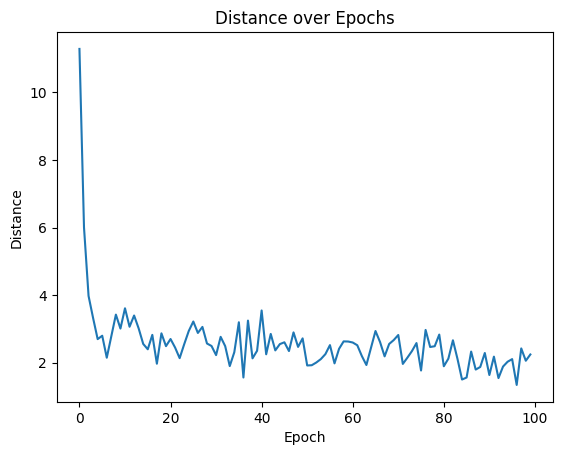

In [4]:
plot_learning_curve('generated_vs_true.csv')

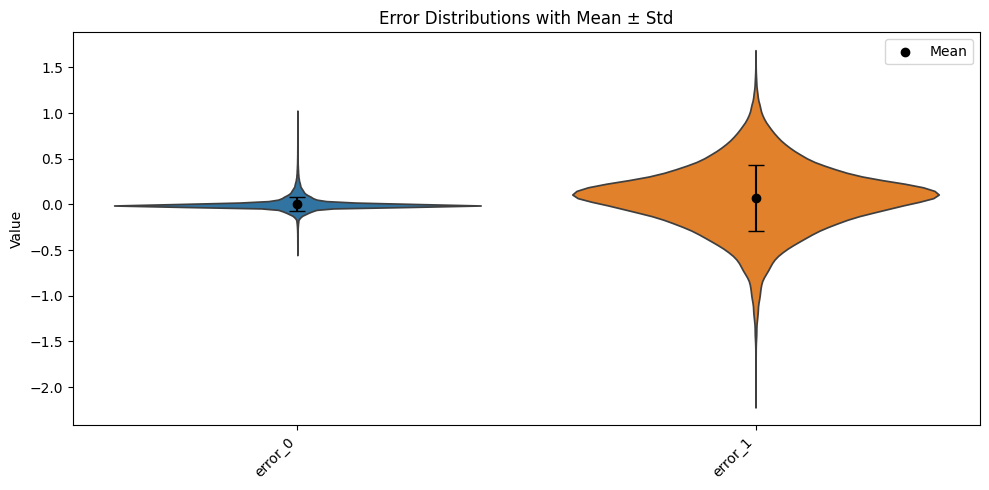

error_0    0.005486
error_1    0.075123
dtype: float64 
 error_0    0.074646
error_1    0.360826
dtype: float64 
              mean       std    median      skew   kurtosis  is_zero_test
error_0  0.005486  0.074646 -0.008105  2.326250  14.010289         False
error_1  0.075123  0.360826  0.089637 -0.247794   1.304691         False


In [2]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

# BINS DISTRIBUTION


In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)

In [ ]:
mydata = prepare_data(pdfs, paths)


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_error_dist.csv')


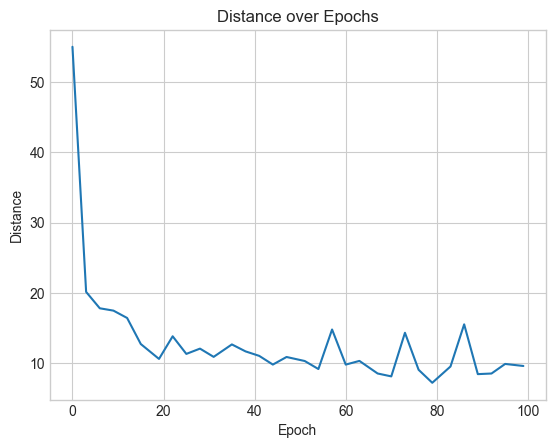

In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [1]:
import pandas as pd

data = pd.read_csv('data/results/generated_vs_true_bins.csv')
data = data['generated']
print(data.iloc[-1:])


1023    [-0.8065932393074036, -0.8494381904602051, -0....
Name: generated, dtype: object


In [2]:
import numpy as np
row = (data.iloc[-1:].values)
print(type(row))
#y=np.array(exec(row[0]), dtype=np.float64)
#print(type(y))

<class 'numpy.ndarray'>


In [ ]:
print(row[0])
x = row[0]
print(type(x))
l = x.split(sep=',')
print(*l, sep='\n')


[-0.8065932393074036, -0.8494381904602051, -0.7710544466972351, -0.8463141322135925, -0.8354984521865845, -0.7546586394309998, -0.833529531955719, -0.7302605509757996, -0.7326045036315918, -0.7048928141593933, -0.7361509799957275, -0.7613071203231812, -0.7146515846252441, -0.7357325553894043, -0.9284422993659973, -0.7624703645706177, -0.722624659538269, -0.7234082221984863, -0.7492651343345642, -0.777708888053894, -0.6884402632713318, -0.7065008878707886, -0.6939764022827148, -0.713860034942627, -0.7020806074142456, -0.9014880657196045, -0.6771376729011536, -0.7405807375907898, -0.6593418717384338, -0.6928648948669434, -0.720999538898468, -0.7883956432342529, -0.6346548795700073, -0.6120287179946899, -0.5369141697883606, -0.758938193321228, -0.5756452083587646, -0.6285544037818909, -0.6480890512466431, -0.6925523281097412, -0.5670021772384644, -0.6574873328208923, -0.7775904536247253, -0.5840715169906616, -0.6573241353034973, -0.5870238542556763, -0.6492022275924683, -0.665372133255004

In [11]:

y = eval(x)
print(type(y))
print(y)

<class 'list'>
[-0.8065932393074036, -0.8494381904602051, -0.7710544466972351, -0.8463141322135925, -0.8354984521865845, -0.7546586394309998, -0.833529531955719, -0.7302605509757996, -0.7326045036315918, -0.7048928141593933, -0.7361509799957275, -0.7613071203231812, -0.7146515846252441, -0.7357325553894043, -0.9284422993659973, -0.7624703645706177, -0.722624659538269, -0.7234082221984863, -0.7492651343345642, -0.777708888053894, -0.6884402632713318, -0.7065008878707886, -0.6939764022827148, -0.713860034942627, -0.7020806074142456, -0.9014880657196045, -0.6771376729011536, -0.7405807375907898, -0.6593418717384338, -0.6928648948669434, -0.720999538898468, -0.7883956432342529, -0.6346548795700073, -0.6120287179946899, -0.5369141697883606, -0.758938193321228, -0.5756452083587646, -0.6285544037818909, -0.6480890512466431, -0.6925523281097412, -0.5670021772384644, -0.6574873328208923, -0.7775904536247253, -0.5840715169906616, -0.6573241353034973, -0.5870238542556763, -0.6492022275924683, -0.

In [12]:
print(type(y[0]))

<class 'float'>


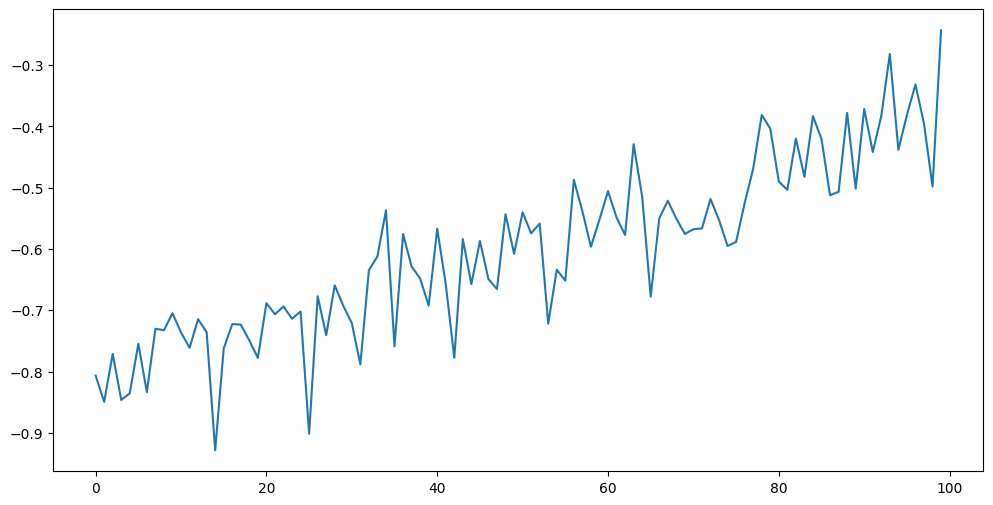

In [ ]:
import matplotlib.pyplot as plt
import ast

#z = eval(x)
#print(z)
#print(y)
#print(type(x[0]))
#l = x.split(sep=',')
#print(*l, sep='n')
# Plot the row variable
plt.figure(figsize=(12, 6))
plt.plot(y)
#plt.title('Last Generated Data Point')
#plt.xlabel('Index')
#plt.ylabel('Value')
#plt.grid(True, alpha=0.3)
#plt.tight_layout()
plt.show()